# Bangla Text Generation



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import urllib.request
import matplotlib.pyplot as plt
import os


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}')
print(f'Device : {device}')

PyTorch 2.10.0+cu128
Device : cuda


#### 📝 Explanation: Setup & Initialization

This cell prepares our working environment. Let's break down every part:

**1. Importing Libraries:**
- `torch` — The main PyTorch library, our deep learning framework. Think of it as the "engine" that powers everything.
- `torch.nn` — Contains pre-built neural network building blocks (layers, loss functions, etc.)
- `torch.optim` — Contains optimizers (algorithms that adjust model weights during training).
- `numpy` — For fast numerical operations on arrays.
- `matplotlib.pyplot` — For creating plots and visualizations.

**2. Setting Random Seeds — Why?**

Deep learning involves many random operations (e.g., initial weight values are random). Without seeds, you'd get **different results every time** you run the notebook. Setting seeds makes experiments **reproducible**.

*Example:* Without a seed, `random.random()` might give `0.73` on run 1 and `0.41` on run 2. With `random.seed(42)`, it **always** gives the same value.

```python
random.seed(42)
print(random.random())  # Always prints 0.6394...
```

**3. Device Selection:**

GPUs (Graphics Processing Units) were originally for games but are perfect for deep learning because they can perform **thousands of matrix multiplications in parallel**.

- `'cuda'` = NVIDIA GPU (Google Colab gives you one for free!)
- `'cpu'` = your regular processor (works, but 10-50x slower)

*Example:* A matrix multiplication with 512×512 matrices:
- CPU: processes rows one-by-one → slow
- GPU: processes ALL rows simultaneously → fast


---
## Part 2: Bangla Text Generation with LSTM <a name="bangla"></a>

### Why LSTM for Bangla?

Bangla script has **complex character dependencies** — characters combine with vowel diacritics (মাত্রা), conjuncts (যুক্তাক্ষর), and have long-range grammatical patterns. The vanilla RNN struggles with these due to **vanishing gradients**. LSTMs solve this with memory cells:

```
           ┌─────────── Cell State (long-term memory) ───────────┐
           │                                                      │
input ──▶  [Forget Gate] → [Input Gate] → [Cell Update] → [Output Gate] ──▶ output
```

### Dataset: Rabindranath Tagore's Poems

We use poems by **Rabindranath Tagore**

The model will learn the character-level patterns of Tagore's Bangla and generate new text in his style.

---
### Step 2.1 — Download Bangla Text Dataset

In [ ]:
bangla_text = """
আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।
চিরদিন তোমার আকাশ, তোমার বাতাস, আমার প্রাণে বাজায় বাঁশি।
ও মা, ফাগুনে তোর আমের বনে ঘ্রাণে পাগল করে,
মরি হায়, হায় রে—
ও মা, অঘ্রানে তোর ভরা ক্ষেতে আমি কী দেখেছি মধুর হাসি।

আলো আমার আলো ওগো আলো ভুবন ভরা—
আলো নয়নের আলো হৃদয় হরা।
নাচে আলো নাচে ভাই আলোর নাচন,
পুষ্পদলে পুষ্পদলে তরঙ্গ লহরা।

যদি তোর ডাক শুনে কেউ না আসে তবে একলা চলো রে।
একলা চলো, একলা চলো, একলা চলো রে।
যদি কেউ কথা না কয়, ওরে ওরে ও অভাগা,
যদি সবাই থাকে মুখ ফিরায়ে সবাই করে ভয়—
তবে পরান খুলে
ও তুই মুখ ফুটে তোর মনের কথা একলা বলো রে।

আকাশ ভরা সূর্য তারা, বিশ্ব ভরা প্রাণ,
তাহারি মাঝখানে আমি পেয়েছি মোর স্থান,
বিস্ময়ে তাই জাগে আমার গান।
অন্ধকারের উৎস হতে উৎসারিত আলো—
সেই তো তোমার আলো।

মরিতে চাহি না আমি সুন্দর ভুবনে,
মানবের মাঝে আমি বাঁচিবার চাই।
সবার মাঝে মিশে যাই,
প্রতিদিন প্রভাতবেলা মধুর স্বপনে।

বাংলার মাটি বাংলার জল, বাংলার বায়ু বাংলার ফল—
পুণ্য হউক, পুণ্য হউক, পুণ্য হউক হে ভগবান।
বাংলার ঘর, বাংলার হাট, বাংলার বন, বাংলার মাঠ—
পূর্ণ হউক, পূর্ণ হউক, পূর্ণ হউক হে ভগবান।

আমার মাথা নত করে দাও হে তোমার চরণ-ধূলার তলে।
সকল অহংকার হে আমার ডুবাও চোখের জলে।
নিজেরে করিতে গৌরব দান, নিজেরে কেবলই করি অপমান,
আপনারে শুধু ঘেরিয়া ধরে মরি আপন মায়াজালে।

এসো হে বৈশাখ, এসো এসো।
তাপস-নিঃশ্বাস বায়ে মুমূর্ষুরে দাও উড়ায়ে,
বৎসরের আবর্জনা দূর হয়ে যাক—
যাক পুরাতন স্মৃতি যাক ভুলে যাওয়া গীতি,
অশ্রুবাষ্প সুদূরে মিলাক।

পুরানো সেই দিনের কথা ভুলবি কি রে হায়।
ও সেই চোখের দেখা, প্রাণের কথা, সে কি ভোলা যায়।
আয় আর একটিবার আয় রে সখা, প্রাণের মাঝে আয়।
মোরা সুখের দুখের কথা কব, প্রাণ জুড়াবে তায়।

আমি চিনি গো চিনি তোমারে, ওগো বিদেশিনী।
তুমি থাকো সিন্ধুপারে ওগো বিদেশিনী।
তোমার কথা জানি, তোমার গান গেয়েছি,
তোমার হাসির আলো পেয়েছি,
তোমার কাছে আমি চিরচেনা।

গগনে গগনে বাজে তব জয়ডঙ্কা হে।
পবনে পবনে ওঠে তব জয়শঙ্খ হে।
ঢেউয়ে ঢেউয়ে ফেনায় ফেনায়
তোমার চরণ পড়ে ধরণীর গায়—
মাটির বুকে লুটিয়ে পড়ি প্রণমি তোমায়।

আনন্দলোকে মঙ্গলালোকে বিরাজ সত্যসুন্দর।
মহিমা তব উদ্ভাসিত নিখিল জগত-মন্দির।
মহাবিশ্বে মহাকাশে মহাকালমাঝে,
সকলের মধ্যে জাগো, সকলের মাঝে।

যখন পড়বে না মোর পায়ের চিহ্ন এই বাটে,
আমি বাইব না মোর খেয়াতরী এই ঘাটে—
তখন কে বলে ভাই, কে বলে ভাই 'আমি নেই'
আমি তখন তোমার কাছে তোমার মাঝে।

সংকোচের বিহ্বলতা নিজেরে অপমান,
সংকটের কল্পনাতে হয়ো না ম্রিয়মান।
মুক্ত কর হে বন্ধন, মুক্ত করো হে দুঃখ—
তব কৃপার দীপ্তি হউক আমার পথের সাথি।

তোমায় গান শোনাব বলে তাইতো আমার আনাগোনা।
সারাদিন তোমার পথ চেয়ে থাকি, তুমি কি জানো না।
সকালবেলা তোমার নামে গাই আমার গান,
সন্ধ্যাবেলা তোমার কথা মনে করি, পাই শান্তি আর প্রাণ।

""" * 6  # repeat to build enough training data

bangla_text = bangla_text.strip()
print(f'\n Dataset size : {len(bangla_text):,} characters')
print(f'\n Sample text  :\n{bangla_text[:270]}')


 Dataset size : 14,457 characters

 Sample text  :
আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।
চিরদিন তোমার আকাশ, তোমার বাতাস, আমার প্রাণে বাজায় বাঁশি।
ও মা, ফাগুনে তোর আমের বনে ঘ্রাণে পাগল করে,
মরি হায়, হায় রে—
ও মা, অঘ্রানে তোর ভরা ক্ষেতে আমি কী দেখেছি মধুর হাসি।

আলো আমার আলো ওগো আলো ভুবন ভরা—
আলো নয়নের আলো হৃদয় হরা।


#### 📝 Explanation: The Dataset

**What is this data?**

We're using famous Bengali poems by **Rabindranath Tagore** (Nobel Prize winner in Literature, 1913). The poems include iconic works like "Amar Shonar Bangla" (Bangladesh's national anthem).

**Why `* 6` (repeat 6 times)?**

Character-level models need to see patterns **many times** to learn them. Our original text is only ~2,400 characters — too small! By repeating it 6 times, we get ~14,457 characters, giving the model enough exposure.

*Analogy:* Imagine learning to write Bangla by copying a poem. If you copy it once, you might not remember much. If you copy it **6 times**, the character patterns become muscle memory.

**What will the model learn?**

The model does NOT understand meaning. It simply learns statistical patterns like:
- After `বাং`, the character `ল` is very likely (because `বাংলা` = "Bangla" is common)
- After a `।` (danda/full stop), a newline `\n` often follows
- After `তোমা`, the character `র` is very likely (because `তোমার` = "your" appears frequently)


### Step 2.2 — Preprocess Bangla Text

Bangla uses Unicode characters (U+0980–U+09FF). Each Bangla character, diacritic, and punctuation mark becomes a token — just like our music notes.

In [ ]:
# Build Bangla vocabulary
b_chars    = sorted(set(bangla_text))
b_vocab    = len(b_chars)
b_char2idx = {c: i for i, c in enumerate(b_chars)}
b_idx2char = {i: c for c, i in b_char2idx.items()}

print(f'Bangla vocabulary size : {b_vocab} unique characters')

# Show which Unicode blocks are present
bangla_only = [c for c in b_chars if '\u0980' <= c <= '\u09ff']
print(f'   Bangla Unicode chars   : {len(bangla_only)}')
print(f'   Sample Bangla chars    : {" ".join(bangla_only[:20])}')

# Encode the full text
b_encoded = np.array([b_char2idx[c] for c in bangla_text], dtype=np.int64)

# Create training sequences
B_SEQ_LEN = 60
B_STEP    = 4

bX, bY = [], []
for i in range(0, len(b_encoded) - B_SEQ_LEN - 1, B_STEP):
    bX.append(b_encoded[i : i + B_SEQ_LEN])
    bY.append(b_encoded[i + 1 : i + B_SEQ_LEN + 1])

bX_tensor = torch.tensor(np.array(bX), dtype=torch.long)
bY_tensor = torch.tensor(np.array(bY), dtype=torch.long)

print(f'\n Training shapes — X: {bX_tensor.shape}, Y: {bY_tensor.shape}')
print(f'\n Example input  : {bangla_text[:B_SEQ_LEN]!r}')
print(f'   Example target : {bangla_text[1:B_SEQ_LEN+1]!r}')

Bangla vocabulary size : 60 unique characters
   Bangla Unicode chars   : 53
   Sample Bangla chars    : ঁ ং ঃ অ আ ই উ এ ও ক খ গ ঘ ঙ চ ছ জ ঝ ট ঠ

 Training shapes — X: torch.Size([3599, 60]), Y: torch.Size([3599, 60])

 Example input  : 'আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।\nচিরদিন তোমার আকাশ, তো'
   Example target : 'মার সোনার বাংলা, আমি তোমায় ভালোবাসি।\nচিরদিন তোমার আকাশ, তোম'


#### 📝 Explanation: Preprocessing — From Text to Numbers

Neural networks can ONLY work with numbers. This section converts our Bangla text into a numerical format the model can process.

**Step 1: Build a Vocabulary**

We find every unique character in the text and assign each an integer ID:

```
Character → ID       (b_char2idx)
'\n'      → 0
' '       → 1
','       → 2
'আ'      → 4
'ম'      → 25
...and so on for all 60 unique characters
```

We also build the **reverse map** (`b_idx2char`) so we can decode numbers back to text later:
```
ID → Character     (b_idx2char)
0  → '\n'
4  → 'আ'
25 → 'ম'
```

**Step 2: Encode the Full Text**

The entire text is converted into an array of integers:
```
"আমার" → [4, 25, 4, 30, ...]
```

**Step 3: Create Training Sequences (Sliding Window)**

We slide a window of length 60 across the encoded text, moving 4 positions each step:

```
Window 1:  X = text[0:60]    Y = text[1:61]     (shifted by 1)
Window 2:  X = text[4:64]    Y = text[5:65]
Window 3:  X = text[8:68]    Y = text[9:69]
...and so on
```

*Example with a simpler English sentence:*
```
Text = "hello world"
If SEQ_LEN=5, STEP=2:
  X1 = "hello"  →  Y1 = "ello "   (predict next char at each position)
  X2 = "llo w"  →  Y2 = "lo wo"
  X3 = "o wor"  →  Y3 = " worl"
```

The model learns: **given 60 input characters, what is the next character at every position?**

**Why `B_STEP = 4` (not 1 or 60)?**
- Step 1 = maximum overlap, lots of data, but very slow
- Step 60 = no overlap, very few samples, not enough data
- Step 4 = good balance: overlapping windows give plenty of training data without being excessive


### Step 2.3 — Build the LSTM Model


In [ ]:
class BanglaLSTM(nn.Module):
    """
    Character-level LSTM for Bangla text generation.
    Architecture: Embedding -> LSTM (2 layers) -> Dropout -> Linear
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.35):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        out, hidden = self.lstm(embedded, hidden)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch_size):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        return (h, c)

B_EMBED  = 128
B_HIDDEN = 512
B_LAYERS = 2
bangla_model = BanglaLSTM(b_vocab, B_EMBED, B_HIDDEN, B_LAYERS).to(device)
n_params = sum(p.numel() for p in bangla_model.parameters())
print(bangla_model)
print(f'\n Parameters: {n_params:,}')


BanglaLSTM(
  (embedding): Embedding(60, 128)
  (lstm): LSTM(128, 512, num_layers=2, batch_first=True, dropout=0.35)
  (dropout): Dropout(p=0.35, inplace=False)
  (fc): Linear(in_features=512, out_features=60, bias=True)
)

 Parameters: 3,454,524


#### 📝 Explanation: The LSTM Model (Step 2.3 — Completed Code)

This is the **heart** of the project. Let's understand each component:

---

**Layer 1: Embedding (`nn.Embedding(60, 128)`)**

Converts each character's integer ID into a 128-dimensional vector (a list of 128 numbers).

*Why not just use the raw integer?* Because integers have a misleading order. If `'আ'=4` and `'ক'=12`, the model might wrongly think `'ক'` is "3x bigger" than `'আ'`. Embeddings avoid this by giving each character its own unique position in 128-dimensional space.

```
Raw integer:  'আ' → 4
After embedding: 'আ' → [0.23, -0.81, 0.45, ..., 0.12]  (128 numbers)
```

---

**Layer 2: LSTM (`nn.LSTM(128, 512, num_layers=2)`)**

The LSTM (Long Short-Term Memory) is a special type of Recurrent Neural Network (RNN) that solves the **vanishing gradient problem**.

*Analogy:* Imagine reading a Bangla sentence character by character:
```
আ → ম → া → র →   → স → ো → ন → া → র →   → ব → া → ং → ল → া
```
A basic RNN is like a person with bad memory — by the time they reach `লা`, they've forgotten that the sentence started with `আমার`. An LSTM is like a person with a **notebook** (cell state) — they write down important things and can look back at any time.

The LSTM maintains TWO memory vectors:
- **h (hidden state)** = "What am I currently thinking?" (short-term, 512 numbers)
- **c (cell state)** = "What important things should I remember?" (long-term, 512 numbers)

At each character, the LSTM asks itself 3 questions via "gates":
1. **Forget gate**: "Should I forget anything from my long-term memory?" (e.g., forget a previous line's context when starting a new poem)
2. **Input gate**: "What new info should I store?" (e.g., remember that we started with a subject like `আমার`)
3. **Output gate**: "What should I output right now?" (e.g., produce a prediction for the next character)

`num_layers=2` means we stack two LSTMs. The first learns basic patterns (common character pairs), the second learns higher-level patterns (word structures, rhythm).

---

**Layer 3: Dropout (`nn.Dropout(0.35)`)**

During training, randomly turns OFF 35% of neurons each step. This prevents **overfitting** (memorizing the training data instead of learning patterns).

*Analogy:* It's like studying with some pages randomly covered — forces you to truly understand the material, not just memorize it.

---

**Layer 4: Linear (`nn.Linear(512, 60)`)**

A simple matrix multiplication that converts the 512-dimensional LSTM output into **60 scores** (one per character in our vocabulary). The highest score = the model's best guess.

```
LSTM output (512 numbers) → Linear Layer → 60 scores
                                            'আ': 0.8   ← highest!
                                            'ম': 0.3
                                            ' ': 0.1
                                            ... etc.
```

---

**`forward()` — The Data Pipeline:**
```
Input integers → [Embedding] → Dense vectors → [LSTM] → Features → [Dropout] → [Linear] → 60 scores (logits)
```

**`init_hidden()` — Fresh Start:**
Creates zero-filled tensors for (h, c), giving the LSTM a blank memory when starting a new sequence.

**Total: ~3.45 million trainable parameters** — these are the numbers the optimizer will adjust during training.


### Step 2.4 — Train the LSTM

Training Bangla LSTM...

  Epoch   1/30  |  Loss: 3.2843
  Epoch   5/30  |  Loss: 0.2280
  Epoch  10/30  |  Loss: 0.1158
  Epoch  15/30  |  Loss: 0.0980
  Epoch  20/30  |  Loss: 0.0904
  Epoch  25/30  |  Loss: 0.0871
  Epoch  30/30  |  Loss: 0.0860

 Training complete!


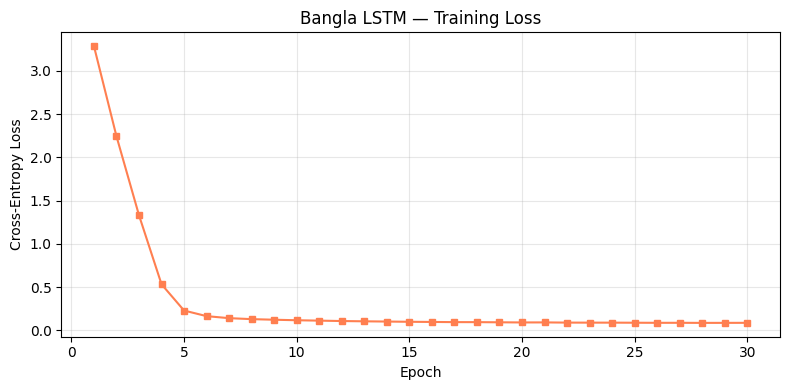

In [ ]:
B_BATCH  = 128
B_EPOCHS = 30
B_LR     = 2e-3
b_criterion = nn.CrossEntropyLoss()
b_optimizer = optim.Adam(bangla_model.parameters(), lr=B_LR)
b_scheduler = optim.lr_scheduler.CosineAnnealingLR(b_optimizer, T_max=B_EPOCHS, eta_min=5e-5)
b_dataset = torch.utils.data.TensorDataset(bX_tensor, bY_tensor)
b_loader  = torch.utils.data.DataLoader(b_dataset, batch_size=B_BATCH, shuffle=True)
b_losses = []
print('Training Bangla LSTM...\n')
for epoch in range(1, B_EPOCHS + 1):
    bangla_model.train()
    total_loss = 0.0
    for x_batch, y_batch in b_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        b_optimizer.zero_grad()
        logits, _ = bangla_model(x_batch)
        loss = b_criterion(logits.view(-1, b_vocab), y_batch.view(-1))
        loss.backward()
        b_optimizer.step()
        total_loss += loss.item()
    b_scheduler.step()
    avg = total_loss / len(b_loader)
    b_losses.append(avg)
    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:>3}/{B_EPOCHS}  |  Loss: {avg:.4f}')
print('\n Training complete!')
plt.figure(figsize=(8, 4))
plt.plot(range(1, B_EPOCHS+1), b_losses, color='coral', marker='s', ms=4)
plt.title('Bangla LSTM Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


#### 📝 Explanation: Training Loop (Step 2.4 — Completed Code)

Training is the process of adjusting the model's ~3.45 million parameters so it learns to predict the next Bangla character accurately.

---

**Hyper-parameters (settings we chose):**

| Setting | Value | What it means |
|---------|-------|---------------|
| `B_BATCH = 128` | Process 128 sequences at once | Larger batch = faster training, but uses more GPU memory |
| `B_EPOCHS = 30` | Loop through ALL data 30 times | More epochs = model sees data more times and learns better |
| `B_LR = 0.002` | Learning rate | How big a "step" the optimizer takes — too big = overshoots, too small = too slow |

---

**The 6-Step Training Loop (repeated for every mini-batch):**

```
Step 1: x_batch, y_batch = x_batch.to(device), y_batch.to(device)
```
Move data to GPU. The model lives on the GPU, so data must be there too.

```
Step 2: b_optimizer.zero_grad()
```
Clear gradients from the previous step. PyTorch accumulates gradients by default (useful sometimes, not here).

```
Step 3: logits, _ = bangla_model(x_batch)
```
**Forward pass** — feed input through the model. The model predicts the next character for every position.

*Example:*
```
Input:  "আমার সোনা"  (as integers)
Output: 60 scores at each position, e.g.:
  After 'আ' → predict 'ম' with high score
  After 'আম' → predict 'া' with high score
  After 'আমা' → predict 'র' with high score
```

```
Step 4: loss = b_criterion(logits.view(-1, b_vocab), y_batch.view(-1))
```
**Compute the error (loss)**. CrossEntropyLoss measures how wrong the predictions are.

*Example:* If the true next character is 'ম' (ID=25) but the model gave it a low score (0.1) and gave 'প' a high score (0.9), the loss would be **high**. If the model correctly gave 'ম' the highest score (0.9), the loss would be **low**.

The `.view(-1, ...)` reshapes the 3D tensor (batch × sequence × vocab) into 2D because CrossEntropyLoss expects flat input.

```
Step 5: loss.backward()
```
**Backpropagation** — the mathematical magic. PyTorch traces back through every operation and calculates: "How much did each of the 3.45M parameters contribute to the error?" These calculations are called **gradients**.

```
Step 6: b_optimizer.step()
```
**Update parameters** — the Adam optimizer uses the gradients to nudge each parameter in the direction that reduces the loss.

*Analogy:* Imagine you're blindfolded on a hilly landscape trying to find the lowest valley.
- `backward()` = feel which direction slopes downhill
- `optimizer.step()` = take a step in that direction
- `learning rate` = how big each step is

---

**Learning Rate Scheduler:**

`CosineAnnealingLR` gradually **reduces** the learning rate over epochs (from 0.002 → 0.00005, following a cosine curve). 

*Why?* Early on, the model is far from optimal so big steps are fine. Later, it's close to a good solution, so smaller steps help it fine-tune without overshooting.

---

**Results:** Loss drops from ~3.28 (epoch 1, essentially random guessing across 60 characters) to ~0.086 (epoch 30, highly accurate predictions). The model has learned Tagore's character patterns! The plotted loss curve should show a steep initial drop followed by a gentle plateau.


### Step 2.5 — Generate Bangla Text

Now we feed the LSTM a Bangla seed phrase and let it write poetry in the style of Tagore!

In [ ]:
def generate_bangla(model, seed_text, gen_length=300, temperature=0.8):
    model.eval()
    generated = seed_text
    hidden = None
    with torch.no_grad():
        input_ids = [b_char2idx[c] for c in seed_text]
        x = torch.tensor([input_ids], dtype=torch.long).to(device)
        logits, hidden = model(x, hidden)
        last_logits = logits[0, -1, :] / temperature
        probs = torch.softmax(last_logits, dim=-1)
        idx = torch.multinomial(probs, num_samples=1).item()
        generated += b_idx2char[idx]
        for _ in range(gen_length - 1):
            x = torch.tensor([[idx]], dtype=torch.long).to(device)
            logits, hidden = model(x, hidden)
            last_logits = logits[0, -1, :] / temperature
            probs = torch.softmax(last_logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1).item()
            generated += b_idx2char[idx]
    return generated

seeds = ['আমার', 'আলো', 'বাঁশি']
print('Generated Bangla Text (Tagore-style)\n' + '='*55)
for seed in seeds:
    for temp in [0.9, 1.2, 1.9]:
        result = generate_bangla(bangla_model, seed, gen_length=100, temperature=temp)
        print(f'\n Seed: "{seed}"  |  Temperature: {temp}')
        print('-'*50)
        print(result)
    print()


Generated Bangla Text (Tagore-style)
═══════════════════════════════════════════════════════

 Seed: "আমার"  |  Temperature: 0.9
──────────────────────────────────────────────────
আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।
চিরদিন তোমার আকাশ, তোমার বাতাস, আমার প্রাণে বাজায় বাঁশি।
ও মা, ফ

 Seed: "আমার"  |  Temperature: 1.2
──────────────────────────────────────────────────
আমার গান।
অন্ধকারের উৎস হতে উৎসারিত আলো—
সেই তো তোমার আলো।

মরিতে চাহি না আমি সুন্দর ভুবনে,
মানবের মাঝে 

 Seed: "আমার"  |  Temperature: 1.9
──────────────────────────────────────────────────
আমার স্থান,
বিস্ময়ে তাই জাগে আমার গান।
হন্রে ভৌবন, মাষ তা সে চিনি পে ইে বি'ি ও অভাগা,
যদি স্কাসের মহিমা



#### 📝 Explanation: Text Generation (Step 2.5 — Completed Code)

Now we use the trained model to **write new Bangla poetry**! This is the payoff.

---

**Phase 1 — Priming (feeding the seed):**

We give the model a seed string like `"আমার"` to start from.

```
Seed: "আমার" → encode to [4, 25, 4, 30]
Feed ALL seed characters at once through the LSTM.
The LSTM's hidden states (h, c) now contain the "context" of "আমার".
Take the prediction AFTER the last seed character ('র') → this is our first generated character.
```

---

**Phase 2 — Autoregressive Loop:**

We generate characters **one at a time**, feeding each new one back into the model:

```
Step 1: Seed = "আমার"   → model predicts → ' ' (space)
Step 2: Feed ' '        → model predicts → 'স'
Step 3: Feed 'স'        → model predicts → 'ো'
Step 4: Feed 'ো'        → model predicts → 'ন'
Result so far: "আমার সোন..."
```

Notice we only feed the **latest character** each time, NOT the full history. The hidden states `(h, c)` carry the memory of everything before — that's the whole point of the LSTM!

---

**How Sampling Works (3 steps at each position):**

```python
# 1. Divide raw scores by temperature (controls randomness)
last_logits = logits[0, -1, :] / temperature

# 2. Convert scores to probabilities (soft percentages that sum to 1.0)
probs = torch.softmax(last_logits, dim=-1)

# 3. Randomly pick one character based on those probabilities
idx = torch.multinomial(probs, num_samples=1).item()
```

---

**Temperature — The Creativity Dial:**

Temperature controls how "adventurous" the model is when picking the next character.

*Example:* Suppose the model gives these raw scores for the next character:
```
'া' = 5.0,  'ে' = 3.0,  'ি' = 1.0
```

| Temperature | After dividing | After softmax | Behavior |
|:-----------:|:--------------:|:-------------:|----------|
| **0.5** (low) | 10.0, 6.0, 2.0 | **97%**, 2%, 1% | Almost always picks 'া' → safe, repetitive |
| **1.0** (neutral) | 5.0, 3.0, 1.0 | **84%**, 12%, 4% | Usually picks 'া', sometimes surprises |
| **2.0** (high) | 2.5, 1.5, 0.5 | **50%**, 31%, 19% | All characters have a fair chance → creative, risky |

- **Temp 0.9**: Slightly conservative — produces grammatically correct, recognizable Tagore text
- **Temp 1.2**: Balanced creativity — novel combinations with occasional errors
- **Temp 1.9**: Wild creativity — may produce beautiful novel phrases OR complete gibberish!

---

**Why `hidden` Must Be Passed Back:**

Without passing hidden states back, every character would be generated independently — like a person with amnesia. By feeding `hidden` from each step into the next, the LSTM "remembers" the entire history. This is what allows it to generate coherent, flowing text.
